# Stage 2: Out-of-Sample Validation of PCA-Based Early Warning Signals Using a UST-Derived Benchmark

## Overview

To evaluate whether latent instability factors generalise across stablecoins, we construct an out-of-sample early warning framework based on principal component analysis (PCA). The approach consists of three key steps: (i) extracting latent factors from training data, (ii) projecting test data onto the learned factor space, and (iii) generating and evaluating early warning signals based on deviations from historical norms.

In this stage, PCA is estimated using training data from TerraUSD, and the resulting factor structure is applied to other stablecoins to assess cross-coin generalisability.

In [1]:
# %pip install pandas pyarrow scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from pathlib import Path

## 0. Methodology

**1. Construction of Latent Factors**

We begin by estimating a fixed PCA model using the training sample of TerraUSD. Let $X_t$ denote the vector of engineered features at time t. Missing values are first imputed using the training sample mean, and all features are standardised to have zero mean and unit variance.

PCA is then applied to the standardised data to obtain a set of orthogonal latent factors:

$Z_t = X_t W$

where W represents the matrix of PCA loadings. These loadings define the latent instability factor space.

A subset of principal components is selected based on Stage 1 exploratory analysis, focusing on components that exhibit meaningful pre-depegging behaviour.

**2. Out-of-Sample Projection**

For each stablecoin, the test-period features are transformed using the same preprocessing steps (imputation and scaling) and projected onto the UST-derived PCA loadings:

$Z_t^{(test)} = X_t^{(test)} W$

This ensures that all stablecoins are evaluated within a common latent factor space, allowing us to assess whether instability patterns identified in UST generalise to other coins.

**3. Standardisation via Benchmark Distribution**

To detect abnormal behaviour, each principal component score is standardised relative to its training-period distribution:

$\tilde{Z}_{t,j} = \frac{Z_{t,j} - \mu_j}{\sigma_j}$

where $\mu_j$ and $\sigma_j$ are the mean and standard deviation of component j computed from the UST training sample.

These z-scores represent the degree of deviation from “normal” latent behaviour.

**4. Signal Construction**

Early warning signals are generated based on extreme deviations in the latent factors.

**4.1 Multi-Factor Threshold Rule**

A signal is triggered when at least k principal components exceed a predefined threshold:

$\text{signal}_t = \mathbf{1}\left( \sum_j \mathbb{I}(|\tilde{Z}_{t,j}| > \tau) \ge k \right)$

where:
* $\tau$ is the z-score threshold,
* k is the minimum number of components required to exceed the threshold.

This rule ensures that signals reflect multi-dimensional instability, rather than isolated fluctuations in a single factor.

**4.2 Persistence Requirement**

To reduce noise, signals must persist for a minimum number of consecutive days:

$\text{signal}_t = 1 \quad \text{only if condition holds for } d \text{ consecutive days}$

This filters out transient spikes and focuses on sustained instability.

**4.3 Cooldown Mechanism**

To prevent repeated signals during the same instability episode, a cooldown period is imposed. Once a signal is triggered, subsequent signals are suppressed for a fixed number of days.

This ensures that signals correspond to the onset of instability periods, rather than continuous alerts.

**5. Definition of Early Warning Labels**

A binary warning label is constructed based on whether a depegging (or instability) event occurs within a forward-looking window of h days:

$$\text{warning}_t =
\begin{cases}
1 & \text{if a depeg occurs within } [t, t+h] \\
0 & \text{otherwise}
\end{cases}$$

This allows signals to be evaluated as early warnings, rather than contemporaneous detections.

**6. Evaluation Metrics**

Performance is assessed at both the day level and the event level.

**6.1 Day-Level Metrics**

Standard classification metrics are computed:
* Precision
* Recall
* F1-score
* Specificity

In addition, we compute:
* Average lead time (days before next event)
* Signal frequency (signals per month)

**6.2 Event-Level Metrics**

To better capture early warning performance, we evaluate detection at the event level.

A depegging event is considered successfully detected if at least one signal occurs within the preceding h-day window.

We report:
* Event hit rate (fraction of events detected)
* Average lead time to event (first signal before event)

This distinction is important, as daily metrics may underestimate performance when signals cluster around events.

**7. Interpretation Framework**

This framework allows us to assess:

* **Generalisation**
	
	Whether UST-derived latent factors capture instability dynamics in other stablecoins.
* **Discrimination**
	
	Whether signals distinguish depegging periods from normal conditions (precision vs specificity).
* **Early Warning Capability**
	
	Whether signals occur sufficiently in advance of events (lead time and event hit rate).

**Summary**

Overall, the methodology combines:
* fixed PCA for interpretability,
* out-of-sample projection for generalisation testing,
* and structured signal rules to balance detection and false alarms.

This enables a rigorous evaluation of whether latent instability signals identified from TerraUSD provide meaningful early warning indicators across different stablecoin designs.

## 1. Load Data
This notebook expects both the `*_clean.parquet` and `*_final.parquet` files.


In [2]:
DATA_DIR = Path("clean_data")

# event / split reference files
dai_clean  = pd.read_parquet(DATA_DIR / "dai_clean.parquet")
pax_clean  = pd.read_parquet(DATA_DIR / "pax_clean.parquet")
usdc_clean = pd.read_parquet(DATA_DIR / "usdc_clean.parquet")
usdt_clean = pd.read_parquet(DATA_DIR / "usdt_clean.parquet")
ust_clean  = pd.read_parquet(DATA_DIR / "ust_clean.parquet")

# modelling files with engineered features
dai_final  = pd.read_parquet(DATA_DIR / "dai_final.parquet")
pax_final  = pd.read_parquet(DATA_DIR / "pax_final.parquet")
usdc_final = pd.read_parquet(DATA_DIR / "usdc_final.parquet")
usdt_final = pd.read_parquet(DATA_DIR / "usdt_final.parquet")
ust_final  = pd.read_parquet(DATA_DIR / "ust_final.parquet")

for df in [dai_clean, pax_clean, usdc_clean, usdt_clean, ust_clean,
           dai_final, pax_final, usdc_final, usdt_final, ust_final]:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

In [3]:
print("Depeg counts")
print("DAI :", int(dai_clean["depeg"].sum()))
print("PAX :", int(pax_clean["depeg"].sum()))
print("USDC:", int(usdc_clean["depeg"].sum()))
print("USDT:", int(usdt_clean["depeg"].sum()))
print("UST :", int(ust_clean.loc[ust_clean["timestamp"] <= "2022-05-11", "depeg"].sum()))

Depeg counts
DAI : 32
PAX : 35
USDC: 32
USDT: 29
UST : 33


## 2. Helper Functions for Splitting and PCA Preparation

In [4]:
def split_by_global_date(df, split_date="2022-01-01", end_date=None, date_col="timestamp"):
    df = df.sort_values(date_col).reset_index(drop=True).copy()
    
    if end_date is not None:
        df = df[df[date_col] <= pd.Timestamp(end_date)].copy()
    
    split_date = pd.Timestamp(split_date)
    
    train = df[df[date_col] <= split_date].copy()
    test  = df[df[date_col] > split_date].copy()
    
    return train, test

def prepare_stablecoin_pca_df(df):
    drop_cols = [
        "depeg", "timeOpen", "timeClose", "timeHigh", "timeLow",
        "open", "high", "low", "close", "volume", "marketCap", "circulatingSupply",
        "depeg_future_1d", "depeg_future_3d", "depeg_future_5d", "depeg_future_7d",
        "depeg_future_14d", "depeg_future_21d", "depeg_future_30d"
    ]
    keep = [c for c in df.columns if c not in drop_cols]
    out = df[keep].copy()
    if "symbol" not in out.columns:
        out["symbol"] = np.nan
    return out

def get_feature_columns(df):
    return [c for c in df.columns if c not in ["timestamp", "symbol"]]

## 3. Train-Test Splits
We adopt a common chronological split at **1 January 2022** across all stablecoins to ensure a consistent and forward-looking evaluation. The training sample captures pre-2022 market dynamics, while the test sample includes major stress events such as the TerraUSD collapse in May 2022 and the USDC depegging episode in March 2023. This design allows us to assess both early-warning capability and cross-coin generalisation under realistic out-of-sample conditions.

In [5]:
global_split_date = "2022-01-01"
# UST: cut at collapse
ust_train, ust_test = split_by_global_date(
    ust_final,
    split_date=global_split_date,
    end_date="2022-05-10"
)

# splits based on modelling files
ust_train_raw, ust_test_raw = split_by_global_date(ust_final, global_split_date)
pax_train_raw,  pax_test_raw  = split_by_global_date(pax_final, global_split_date)
usdc_train_raw, usdc_test_raw = split_by_global_date(usdc_final, global_split_date)
usdt_train_raw, usdt_test_raw = split_by_global_date(usdt_final, global_split_date)
dai_train_raw,  dai_test_raw  = split_by_global_date(dai_final, global_split_date)

# keep only PCA-ready columns
ust_train_pca  = prepare_stablecoin_pca_df(ust_train_raw)
ust_test_pca   = prepare_stablecoin_pca_df(ust_test_raw)
usdc_test_pca  = prepare_stablecoin_pca_df(usdc_test_raw)
usdt_test_pca  = prepare_stablecoin_pca_df(usdt_test_raw)
dai_test_pca   = prepare_stablecoin_pca_df(dai_test_raw)
pax_test_pca   = prepare_stablecoin_pca_df(pax_test_raw)

split_summary = pd.DataFrame([
    {"coin":"UST",  "train_start":ust_train_raw.timestamp.min(),  "train_end":ust_train_raw.timestamp.max(),  "train_size": len(ust_train_raw), "test_start":ust_test_raw.timestamp.min(),  "test_end":ust_test_raw.timestamp.max(), "test_size": len(ust_test_raw),  "train_depegs":int(ust_train_raw.depeg.sum()),  "test_depegs":int(ust_test_raw.depeg.sum())},
    {"coin":"USDC", "train_start":usdc_train_raw.timestamp.min(), "train_end":usdc_train_raw.timestamp.max(), "train_size": len(usdc_train_raw), "test_start":usdc_test_raw.timestamp.min(), "test_end":usdc_test_raw.timestamp.max(), "test_size": len(usdc_test_raw), "train_depegs":int(usdc_train_raw.depeg.sum()), "test_depegs":int(usdc_test_raw.depeg.sum())},
    {"coin":"DAI",  "train_start":dai_train_raw.timestamp.min(),  "train_end":dai_train_raw.timestamp.max(),  "train_size": len(dai_train_raw), "test_start":dai_test_raw.timestamp.min(),  "test_end":dai_test_raw.timestamp.max(),  "test_size": len(dai_test_raw),  "train_depegs":int(dai_train_raw.depeg.sum()),  "test_depegs":int(dai_test_raw.depeg.sum())},
    {"coin":"USDT", "train_start":usdt_train_raw.timestamp.min(), "train_end":usdt_train_raw.timestamp.max(), "train_size": len(usdt_train_raw), "test_start":usdt_test_raw.timestamp.min(), "test_end":usdt_test_raw.timestamp.max(), "test_size": len(usdt_test_raw), "train_depegs":int(usdt_train_raw.depeg.sum()), "test_depegs":int(usdt_test_raw.depeg.sum())},
    {"coin":"PAX",  "train_start":pax_train_raw.timestamp.min(),  "train_end":pax_train_raw.timestamp.max(),  "train_size": len(pax_train_raw), "test_start":pax_test_raw.timestamp.min(),  "test_end":pax_test_raw.timestamp.max(),  "test_size": len(pax_test_raw),  "train_depegs":int(pax_train_raw.depeg.sum()),  "test_depegs":int(pax_test_raw.depeg.sum())},
])
split_summary

,coin,train_start,train_end,train_size,test_start,test_end,test_size,train_depegs,test_depegs
0,UST,2020-12-25 23:59:59,2021-12-31 23:59:59,372,2022-01-01 23:59:59,2022-05-10 23:59:59,130,29,4
1,USDC,2020-12-25 23:59:59,2021-12-31 23:59:59,372,2022-01-01 23:59:59,2026-03-19 23:59:59,1539,26,6
2,DAI,2020-12-25 23:59:59,2021-12-31 23:59:59,372,2022-01-01 23:59:59,2026-03-19 23:59:59,1539,21,2
3,USDT,2020-12-25 23:59:59,2021-12-31 23:59:59,372,2022-01-01 23:59:59,2026-03-19 23:59:59,1539,10,18
4,PAX,2020-12-25 23:59:59,2021-12-31 23:59:59,372,2022-01-01 23:59:59,2026-03-19 23:59:59,1539,4,31


In [6]:
def get_feature_columns(df):
    exclude_cols = ["timestamp", "symbol", "Unnamed: 0"]

    candidate_cols = [c for c in df.columns if c not in exclude_cols]

    numeric_cols = [
        c for c in candidate_cols
        if pd.api.types.is_numeric_dtype(df[c])
    ]

    return numeric_cols

## 4. Fit the **UST Benchmark PCA**

This is the key step:
- imputer is fitted on **UST training**
- scaler is fitted on **UST training**
- PCA is fitted on **UST training**
- every other coin is projected into the **same UST latent-factor space**

In [7]:
def fit_ust_benchmark_pca(ust_train_df, n_components=10):
    numeric_cols = get_feature_columns(ust_train_df)

    imputer = SimpleImputer(strategy="mean")
    X_train_imp = imputer.fit_transform(ust_train_df[numeric_cols])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp)

    n_components = min(n_components, X_train_scaled.shape[1])
    pca = PCA(n_components=n_components)
    X_train_pcs = pca.fit_transform(X_train_scaled)

    pc_cols = [f"PC{i+1}" for i in range(n_components)]

    return {
        "numeric_cols": numeric_cols,
        "imputer": imputer,
        "scaler": scaler,
        "pca": pca,
        "loadings": pd.DataFrame(pca.components_.T, index=numeric_cols, columns=pc_cols),
        "explained_variance": pd.Series(pca.explained_variance_ratio_, index=pc_cols),
        "pc_scores_train": pd.DataFrame(X_train_pcs, columns=pc_cols, index=ust_train_df.index),
    }

ust_benchmark = fit_ust_benchmark_pca(ust_train_pca, n_components=10)
ust_benchmark["explained_variance"].head(10)

PC1     0.232132
PC2     0.192776
PC3     0.123152
PC4     0.074458
PC5     0.060394
PC6     0.054393
PC7     0.052208
PC8     0.046833
PC9     0.035319
PC10    0.028549
dtype: float64

In [8]:
ust_benchmark["loadings"].iloc[:, :10].head(20)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
percent_change_24h,0.058220,-0.245305,0.321285,-0.308513,0.335601,0.022864,-0.128262,-0.031597,0.017725,-0.123051
percent_change_7d,0.109113,-0.251174,0.315499,-0.032532,-0.197406,-0.066173,-0.024579,-0.128436,-0.262019,0.273118
percent_change_30d,0.108579,-0.246057,0.307803,0.234586,-0.124106,0.365758,-0.164005,-0.007110,-0.035119,-0.079966
volume_percent_change_24h,-0.087252,-0.044893,0.181173,0.125710,0.648001,-0.234443,0.120456,-0.055267,0.252593,-0.175652
volume_percent_change_7d,-0.092944,-0.016248,0.163097,0.449869,0.284836,-0.254208,0.219369,-0.083561,-0.356463,0.528960
volume_percent_change_30d,-0.155343,-0.099576,0.195380,0.523362,-0.091313,0.202946,-0.177143,-0.081462,0.047650,-0.376305
market_cap_percent_change_24h,0.162087,0.383107,0.094728,0.149578,-0.246208,-0.179128,-0.093193,-0.075673,0.010569,0.053556
market_cap_percent_change_7d,0.234853,0.332544,0.240449,0.025547,0.023461,-0.081103,-0.015959,0.001315,0.181852,-0.075326
market_cap_percent_change_30d,0.345846,0.097351,-0.079798,0.043795,0.195568,0.433684,0.226754,0.032056,0.098229,0.166583
circulating_supply_percent_change_24h,0.228044,0.272474,0.302959,-0.012503,-0.084546,-0.192339,-0.175579,-0.107332,0.020638,-0.007177


**PC10**
* Captures short-term market stress driven by volume spikes, sentiment shifts, and rapid price deviations, serving as an early indicator of instability.

**PC3**
* Reflects persistent structural imbalances, including sustained price movements, peg pressure, and supply changes, indicating gradual deterioration in stability.

**PC1**
* Represents broader market conditions such as capital inflows and growth dynamics, which may influence but do not directly drive instability.

## 5. Project Each Coin into the UST Factor Space

In [9]:
def project_into_ust_space(df_pca, ust_benchmark):
    numeric_cols = ust_benchmark["numeric_cols"]

    # keep only features shared with UST benchmark and in same order
    missing_cols = [c for c in numeric_cols if c not in df_pca.columns]
    if missing_cols:
        raise ValueError(f"Missing columns relative to UST benchmark: {missing_cols}")

    X = df_pca[numeric_cols].copy()
    X_imp = ust_benchmark["imputer"].transform(X)
    X_scaled = ust_benchmark["scaler"].transform(X_imp)
    X_pcs = ust_benchmark["pca"].transform(X_scaled)

    pc_cols = [f"PC{i+1}" for i in range(X_pcs.shape[1])]
    return pd.DataFrame(X_pcs, columns=pc_cols, index=df_pca.index)

ust_train_proj = ust_benchmark["pc_scores_train"].copy()
ust_test_proj  = project_into_ust_space(ust_test_pca, ust_benchmark)
usdc_test_proj = project_into_ust_space(usdc_test_pca, ust_benchmark)
dai_test_proj  = project_into_ust_space(dai_test_pca, ust_benchmark)
usdt_test_proj = project_into_ust_space(usdt_test_pca, ust_benchmark)
pax_test_proj  = project_into_ust_space(pax_test_pca, ust_benchmark)

ust_test_proj.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
372,1.660206,0.648014,-0.407753,-0.515164,-0.085075,-0.131489,-0.154888,-0.688928,-0.700982,-0.539885
373,1.666130,0.615274,-0.401366,-0.575536,-0.227787,-0.062752,-0.201227,-0.665334,-0.450551,-0.393287
374,1.429711,0.193128,-0.160821,-0.270371,0.550654,-0.134845,-0.096812,0.070512,-0.423878,-0.337930
375,1.507118,0.428963,-0.425609,-0.211598,0.345332,-0.176567,-0.017521,0.114286,-0.683305,-0.408039
376,1.287035,0.581902,-0.073093,0.341691,1.147058,-0.553458,0.170079,-0.052042,-0.608715,-0.352474


## 6. Define the **UST Benchmark Distribution**

We compute the anomaly benchmark from **UST training PC scores only**.

### Main Setting
Use **all UST training days**.  
This is a practical benchmark because it captures both normal and mild-stress conditions in the benchmark coin.


In [10]:
UST_BENCHMARK_PCS = [9, 2, 0]   # [0] = PC1 only, [0, 2] = PC1 and PC3

def make_ust_benchmark_stats(ust_benchmark, selected_pcs):
    pc_cols = [f"PC{i+1}" for i in selected_pcs]
    train_scores = ust_benchmark["pc_scores_train"][pc_cols].copy()
    mu = train_scores.mean()
    sigma = train_scores.std(ddof=0).replace(0, np.nan)
    return {"pc_cols": pc_cols, "mu": mu, "sigma": sigma, "train_scores": train_scores}

benchmark_stats = make_ust_benchmark_stats(ust_benchmark, UST_BENCHMARK_PCS)
benchmark_stats["mu"], benchmark_stats["sigma"]

(PC10    3.342607e-17
 PC3    -1.910061e-17
 PC1    -1.528049e-16
 dtype: float64,
 PC10    0.774298
 PC3     1.608166
 PC1     2.207891
 dtype: float64)

## 7. Compute Test Z-Scores and Signals

For every coin:
- project into UST space
- compute z-scores using **UST training** mean and sd
- generate an anomaly signal


In [11]:
def compute_test_zscores(projected_scores, benchmark_stats):
    pc_cols = benchmark_stats["pc_cols"]
    z = (projected_scores[pc_cols] - benchmark_stats["mu"]) / benchmark_stats["sigma"]
    return z

def make_signal_from_zscores(z_df, threshold=3.0, min_pcs=2, consecutive_days=1):
    exceed_count = (z_df.abs() > threshold).sum(axis=1)
    raw_signal = (exceed_count >= min_pcs).astype(int)

    if consecutive_days <= 1:
        return raw_signal.rename("signal")

    rolling_sum = raw_signal.rolling(
        window=consecutive_days,
        min_periods=consecutive_days
    ).sum()

    signal = (rolling_sum >= consecutive_days).astype(int).fillna(0)
    return signal.rename("signal")

def apply_cooldown(signal, cooldown_days=7):
    signal = signal.copy().astype(int).reset_index(drop=True)
    cooled = pd.Series(0, index=signal.index, dtype=int)

    last_fire = -10**9
    for i in range(len(signal)):
        if signal.iloc[i] == 1 and (i - last_fire) > cooldown_days:
            cooled.iloc[i] = 1
            last_fire = i

    return cooled.rename("signal")

def attach_signal_metadata(test_raw_df, z_df, signal):
    out = test_raw_df[["timestamp", "depeg"]].copy().reset_index(drop=True)
    out = pd.concat([out, z_df.reset_index(drop=True)], axis=1)
    out["signal"] = signal.reset_index(drop=True)
    return out

Requiring at least 2 PCs to exceed threshold means:

* not every isolated spike becomes a signal
* signal now reflects multi-dimensional instability
* false alarms should drop a lot

## 8. Build Warning Labels and Evaluate Performance

In [12]:
def build_warning_labels(df, window_days=7, date_col="timestamp", depeg_col="depeg"):
    df = df.copy().sort_values(date_col).reset_index(drop=True)
    event_dates = df.loc[df[depeg_col] == 1, date_col].tolist()

    warning = np.zeros(len(df), dtype=int)
    lead_time_to_next_depeg = [np.nan] * len(df)

    for i, t in enumerate(df[date_col]):
        future_events = [d for d in event_dates if d >= t]
        if future_events:
            next_event = min(future_events)
            delta = (next_event - t).days
            lead_time_to_next_depeg[i] = delta
            if 0 <= delta <= window_days:
                warning[i] = 1

    df["warning_label"] = warning
    df["days_to_next_depeg"] = lead_time_to_next_depeg
    return df

def get_event_starts(df, date_col="timestamp", depeg_col="depeg"):
    df = df.sort_values(date_col).reset_index(drop=True).copy()
    event_start_mask = (df[depeg_col] == 1) & (df[depeg_col].shift(1, fill_value=0) == 0)
    return df.loc[event_start_mask, date_col].tolist()

def compute_event_metrics(labeled_df, warning_window_days=7):
    event_starts = get_event_starts(labeled_df)

    hits = 0
    lead_times = []

    for event_date in event_starts:
        window_start = event_date - pd.Timedelta(days=warning_window_days)
        prior_signals = labeled_df[
            (labeled_df["timestamp"] >= window_start) &
            (labeled_df["timestamp"] <= event_date) &
            (labeled_df["signal"] == 1)
        ]

        if len(prior_signals) > 0:
            hits += 1
            first_signal_date = prior_signals["timestamp"].min()
            lead_times.append((event_date - first_signal_date).days)

    n_events = len(event_starts)
    event_hit_rate = hits / n_events if n_events > 0 else np.nan
    avg_event_lead = np.mean(lead_times) if lead_times else np.nan

    return {
        "n_events": n_events,
        "event_hits": hits,
        "event_hit_rate": event_hit_rate,
        "avg_event_lead_time_days": avg_event_lead,
    }

def compute_metrics(labeled_df, coin=""):
    y_true = labeled_df["warning_label"].astype(int)
    y_pred = labeled_df["signal"].astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = 2 * precision * recall / (precision + recall) if pd.notna(precision) and pd.notna(recall) and (precision + recall) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    signal_days = labeled_df.loc[labeled_df["signal"] == 1, "days_to_next_depeg"]
    valid_leads = signal_days[(signal_days >= 0) & signal_days.notna()]
    avg_lead_time = float(valid_leads.mean()) if len(valid_leads) > 0 else np.nan

    signals_per_month = labeled_df["signal"].sum() / max(labeled_df["timestamp"].dt.to_period("M").nunique(), 1)

    out = {
        "coin": coin,
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "specificity": specificity,
        "avg_lead_time_days": avg_lead_time,
        "signals_per_month": signals_per_month,
        "n_test_days": len(labeled_df),
        "n_test_depegs": int(labeled_df["depeg"].sum()),
    }

    out.update(compute_event_metrics(labeled_df))
    return out

In [26]:
def run_ust_benchmark_eval(
    coin,
    test_raw_df,
    projected_scores,
    benchmark_stats,
    threshold=3.0,
    min_pcs=2,
    consecutive_days=2,
    cooldown_days=7,
    warning_window_days=7
):
    z_df = compute_test_zscores(projected_scores, benchmark_stats)

    raw_signal = make_signal_from_zscores(
        z_df,
        threshold=threshold,
        min_pcs=min_pcs,
        consecutive_days=consecutive_days
    )

    final_signal = apply_cooldown(raw_signal, cooldown_days=cooldown_days)

    combined = attach_signal_metadata(test_raw_df, z_df, final_signal)
    combined["raw_signal"] = raw_signal.reset_index(drop=True)

    labeled = build_warning_labels(combined, window_days=warning_window_days)
    metrics = compute_metrics(labeled, coin=coin)

    return {
        "coin": coin,
        "zscores": z_df,
        "combined": combined,
        "labeled": labeled,
        "raw_signal": raw_signal,
        "final_signal": final_signal,
        "metrics": metrics,
    }

### Main Model

In [24]:
THRESHOLD = 3.5
MIN_PCS = 2
CONSECUTIVE_DAYS = 2
COOLDOWN_DAYS = 7
WARNING_WINDOW_DAYS = 7

In [27]:
ust_result  = run_ust_benchmark_eval("UST",  ust_test_raw,  ust_test_proj,  benchmark_stats, THRESHOLD, MIN_PCS, CONSECUTIVE_DAYS, WARNING_WINDOW_DAYS)
usdc_result = run_ust_benchmark_eval("USDC", usdc_test_raw, usdc_test_proj, benchmark_stats, THRESHOLD, MIN_PCS, CONSECUTIVE_DAYS, WARNING_WINDOW_DAYS)
dai_result  = run_ust_benchmark_eval("DAI",  dai_test_raw,  dai_test_proj,  benchmark_stats, THRESHOLD, MIN_PCS, CONSECUTIVE_DAYS, WARNING_WINDOW_DAYS)
usdt_result = run_ust_benchmark_eval("USDT", usdt_test_raw, usdt_test_proj, benchmark_stats, THRESHOLD, MIN_PCS, CONSECUTIVE_DAYS, WARNING_WINDOW_DAYS)
pax_result  = run_ust_benchmark_eval("PAX",  pax_test_raw,  pax_test_proj,  benchmark_stats, THRESHOLD, MIN_PCS, CONSECUTIVE_DAYS, WARNING_WINDOW_DAYS)

results = {
    "UST": ust_result,
    "USDC": usdc_result,
    "DAI": dai_result,
    "USDT": usdt_result,
    "PAX": pax_result,
}

pd.DataFrame([r["metrics"] for r in results.values()]).set_index("coin")

,tp,fp,fn,tn,precision,recall,f1,specificity,avg_lead_time_days,signals_per_month,n_test_days,n_test_depegs,n_events,event_hits,event_hit_rate,avg_event_lead_time_days
coin,,,,,,,,,,,,,,,,
UST,1,0,17,112,1.000000,0.055556,0.105263,1.000000,0.000000,0.200000,130,4,2,0,0.000000,NaN
USDC,2,170,24,1343,0.011628,0.076923,0.020202,0.887640,131.257143,3.372549,1539,6,3,2,0.666667,3.500000
DAI,1,172,8,1358,0.005780,0.111111,0.010989,0.887582,140.771429,3.392157,1539,2,1,1,1.000000,4.000000
USDT,7,165,60,1307,0.040698,0.104478,0.058577,0.887908,147.616766,3.372549,1539,18,7,6,0.857143,2.833333
PAX,21,151,156,1211,0.122093,0.118644,0.120344,0.889134,39.968085,3.372549,1539,31,27,27,1.000000,3.296296


**Conclusion** 
* PCA-based latent factors exhibit limited day-level predictive precision but demonstrate a stronger ability to identify instability episodes in advance, suggesting their usefulness as early-warning indicators at the event level rather than for continuous monitoring. However, the low precision and the presence of widespread signals indicate that these factors primarily capture broad market stress rather than depegging-specific risk. Furthermore, the use of UST-based standardisation highlights limitations in cross-coin calibration, as differences in scale and volatility across stablecoins can lead to systematic over-detection. Overall, while latent factors provide useful signals of instability, effective early warning requires accounting for coin-specific dynamics.

### Robustness Check

In [16]:
THRESHOLD = 3.5
MIN_PCS = 1
CONSECUTIVE_DAYS = 2
COOLDOWN_DAYS = 7
WARNING_WINDOW_DAYS = 7

In [17]:
ust_result1  = run_ust_benchmark_eval("UST",  ust_test_raw,  ust_test_proj,  benchmark_stats, THRESHOLD, MIN_PCS, CONSECUTIVE_DAYS, WARNING_WINDOW_DAYS)
usdc_result1 = run_ust_benchmark_eval("USDC", usdc_test_raw, usdc_test_proj, benchmark_stats, THRESHOLD, MIN_PCS, CONSECUTIVE_DAYS, WARNING_WINDOW_DAYS)
dai_result1  = run_ust_benchmark_eval("DAI",  dai_test_raw,  dai_test_proj,  benchmark_stats, THRESHOLD, MIN_PCS, CONSECUTIVE_DAYS, WARNING_WINDOW_DAYS)
usdt_result1 = run_ust_benchmark_eval("USDT", usdt_test_raw, usdt_test_proj, benchmark_stats, THRESHOLD, MIN_PCS, CONSECUTIVE_DAYS, WARNING_WINDOW_DAYS)
pax_result1  = run_ust_benchmark_eval("PAX",  pax_test_raw,  pax_test_proj,  benchmark_stats, THRESHOLD, MIN_PCS, CONSECUTIVE_DAYS, WARNING_WINDOW_DAYS)

results1 = {
    "UST": ust_result1,
    "USDC": usdc_result1,
    "DAI": dai_result1,
    "USDT": usdt_result1,
    "PAX": pax_result1,
}

pd.DataFrame([r["metrics"] for r in results1.values()]).set_index("coin")

,tp,fp,fn,tn,precision,recall,f1,specificity,avg_lead_time_days,signals_per_month,n_test_days,n_test_depegs,n_events,event_hits,event_hit_rate,avg_event_lead_time_days
coin,,,,,,,,,,,,,,,,
UST,1,0,17,112,1.000000,0.055556,0.105263,1.000000,0.000000,0.200000,130,4,2,0,0.000000,NaN
USDC,2,170,24,1343,0.011628,0.076923,0.020202,0.887640,131.257143,3.372549,1539,6,3,2,0.666667,3.500000
DAI,1,172,8,1358,0.005780,0.111111,0.010989,0.887582,140.857143,3.392157,1539,2,1,1,1.000000,4.000000
USDT,7,165,60,1307,0.040698,0.104478,0.058577,0.887908,147.616766,3.372549,1539,18,7,6,0.857143,2.833333
PAX,24,149,153,1213,0.138728,0.135593,0.137143,0.890602,41.757895,3.392157,1539,31,27,27,1.000000,3.740741


**Conclusion**
* Requiring confirmation across multiple latent factors does not significantly improve predictive performance, suggesting that instability signals tend to co-move across dimensions. Relaxing the signal rule to allow any principal component to trigger a signal yields only marginal improvements in recall and event detection, indicating that different components often capture overlapping aspects of instability.

However, both specifications highlight a clear trade-off between detection and false alarm control, with precision remaining low at the daily level. Moreover, the results suggest that the apparent co-movement of signals may be influenced by differences in scale across stablecoins when using UST-based standardisation. As a result, while PCA identifies periods of elevated stress, the signals are not well-calibrated for distinguishing depegging-specific risk, and further adjustment for coin-specific distributions is necessary.

**Projecting UST-derived latent factors onto other stablecoins yields high event-level detection rates, suggesting that these factors respond to periods of elevated market stress. However, the extremely large deviations observed in the projected z-scores indicate that the UST-based distribution provides a poor benchmark for cross-coin comparison. As a result, the signals may reflect differences in scale and volatility across stablecoins rather than purely shared instability dynamics. This highlights that while some aspects of instability may be common, accurate early warning detection requires accounting for coin-specific distributions.**

## 9. Plot Timelines

These plots show see whether the UST-benchmark z-scores rise before depegs.


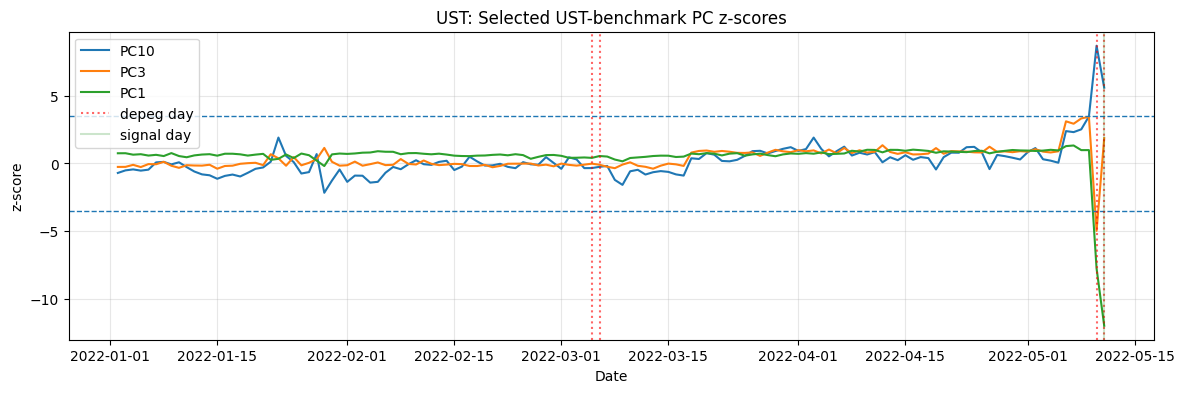

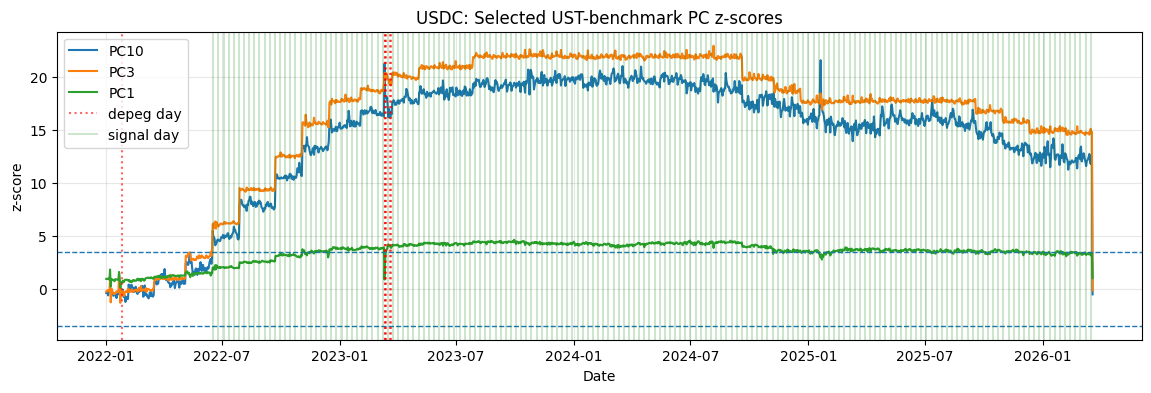

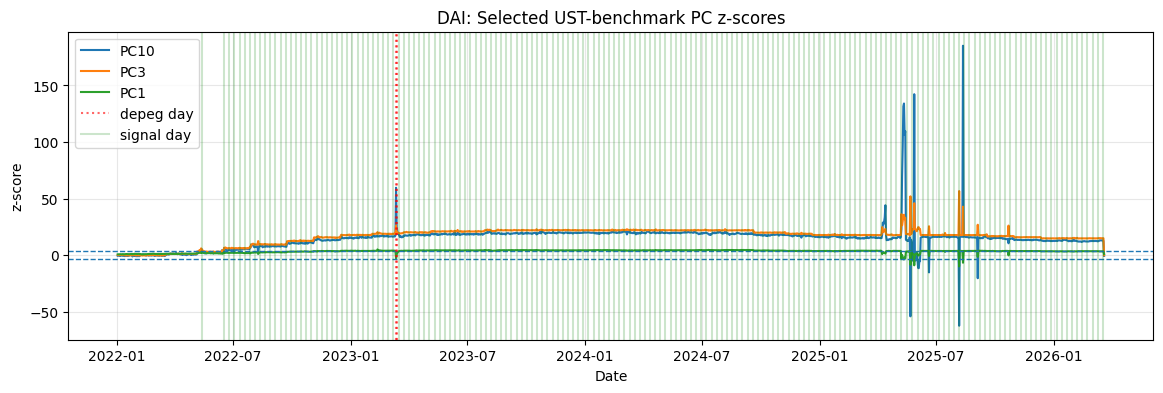

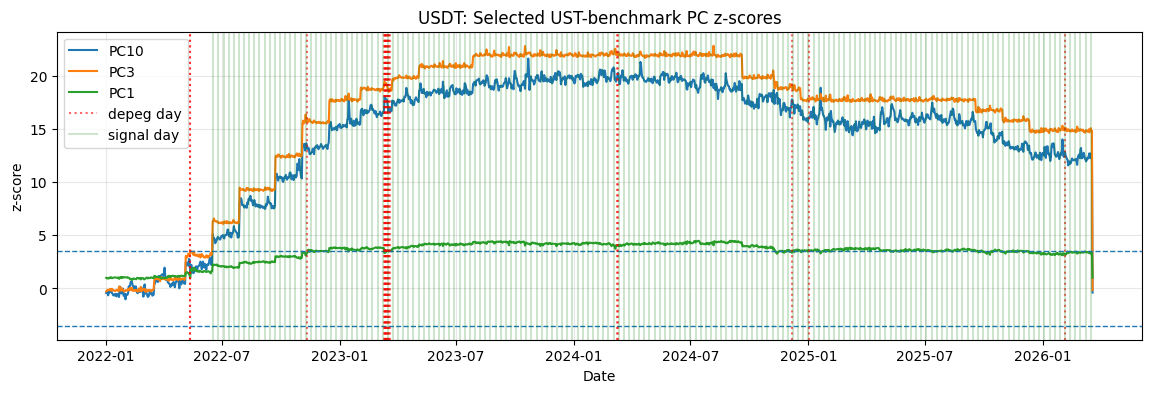

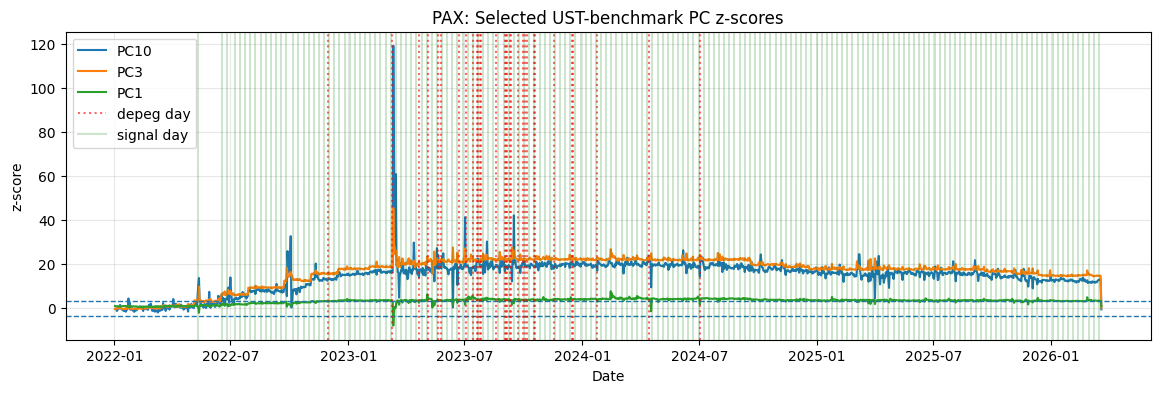

In [29]:
def plot_signal_timeline(result, pc_cols, threshold=3.0, figsize=(14, 4)):
    coin = result["coin"]
    df = result["labeled"].copy()

    fig, ax = plt.subplots(figsize=figsize)

    for c in pc_cols:
        ax.plot(df["timestamp"], df[c], label=c, linewidth=1.5)

    ax.axhline(threshold, linestyle="--", linewidth=1)
    ax.axhline(-threshold, linestyle="--", linewidth=1)

    depeg_dates = df.loc[df["depeg"] == 1, "timestamp"]
    for i, d in enumerate(depeg_dates):
        ax.axvline(d, color="red", linestyle=":", alpha=0.6,
                   label="depeg day" if i == 0 else None)

    signal_dates = df.loc[df["signal"] == 1, "timestamp"]
    for i, d in enumerate(signal_dates):
        ax.axvline(d, color="green", linestyle="-", alpha=0.2,
                   label="signal day" if i == 0 else None)

    ax.set_title(f"{coin}: Selected UST-benchmark PC z-scores")
    ax.set_xlabel("Date")
    ax.set_ylabel("z-score")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    plt.show()

pc_cols = benchmark_stats["pc_cols"]

plot_signal_timeline(ust_result, pc_cols, threshold=THRESHOLD)
plot_signal_timeline(usdc_result, pc_cols, threshold=THRESHOLD)
plot_signal_timeline(dai_result, pc_cols, threshold=THRESHOLD)
plot_signal_timeline(usdt_result, pc_cols, threshold=THRESHOLD)
plot_signal_timeline(pax_result, pc_cols, threshold=THRESHOLD)

**The extreme z-scores observed for other stablecoins indicate that UST-derived factor distributions do not provide a stable benchmark for cross-coin comparison.**

## 10. Grouped Interpretation Table

Table summarises the performance of the UST-based PCA benchmark across different stablecoins. While event-level detection appears strong in some cases, the extremely low precision and persistent signal generation reflect limitations in cross-coin calibration, as the UST-derived distribution does not provide an appropriate benchmark for other stablecoins.

In [33]:
grouped_results = pd.DataFrame([r["metrics"] for r in results.values()])

grouped_results = grouped_results[[
    "coin", "precision", "recall", "f1", "specificity",
    "avg_lead_time_days", "signals_per_month", "tp", "fp", "fn", "tn", "n_test_depegs"
]]
grouped_results

,coin,precision,recall,f1,specificity,avg_lead_time_days,signals_per_month,tp,fp,fn,tn,n_test_depegs
0,UST,1.000000,0.055556,0.105263,1.000000,0.000000,0.200000,1,0,17,112,4
1,USDC,0.011628,0.076923,0.020202,0.887640,131.257143,3.372549,2,170,24,1343,6
2,DAI,0.005780,0.111111,0.010989,0.887582,140.771429,3.392157,1,172,8,1358,2
3,USDT,0.040698,0.104478,0.058577,0.887908,147.616766,3.372549,7,165,60,1307,18
4,PAX,0.122093,0.118644,0.120344,0.889134,39.968085,3.372549,21,151,156,1211,31


## 11. Loading Inspection

In [34]:
selected_cols = [f"PC{i+1}" for i in UST_BENCHMARK_PCS]
for col in selected_cols:
    print(f"\nTop positive loadings for {col}")
    display(ust_benchmark["loadings"][col].sort_values(ascending=False).head(10).to_frame("loading"))
    print(f"Top negative loadings for {col}")
    display(ust_benchmark["loadings"][col].sort_values(ascending=True).head(10).to_frame("loading"))


Top positive loadings for PC10


,loading
volume_percent_change_7d,0.528960
fear_greed_index,0.454884
percent_change_7d,0.273118
price_deviation_5d,0.253374
abs_peg_error,0.173343
market_cap_percent_change_30d,0.166583
circulating_supply_percent_change_30d,0.164208
downward_price_deviation_5d,0.124325
peg_error,0.120455
market_cap_percent_change_24h,0.053556


Top negative loadings for PC10


,loading
volume_percent_change_30d,-0.376305
realized_daily_volatility,-0.202694
volume_percent_change_24h,-0.175652
percent_change_24h,-0.123051
downward_price_deviation_30d,-0.105862
percent_change_30d,-0.079966
market_cap_percent_change_7d,-0.075326
circulating_supply_percent_change_7d,-0.045590
price_deviation_30d,-0.039237
circulating_supply_percent_change_24h,-0.007177



Top positive loadings for PC3


...

,loading
abs_peg_error,-0.108463
market_cap_percent_change_30d,-0.079798
circulating_supply_percent_change_30d,-0.070977
realized_daily_volatility,0.008326
fear_greed_index,0.025644
fed_funds_rate,0.085025
market_cap_percent_change_24h,0.094728
downward_price_deviation_5d,0.143710
volume_percent_change_7d,0.163097
volume_percent_change_24h,0.181173



Top positive loadings for PC1


,loading
circulating_supply_percent_change_30d,0.347847
market_cap_percent_change_30d,0.345846
circulating_supply_percent_change_7d,0.249179
market_cap_percent_change_7d,0.234853
circulating_supply_percent_change_24h,0.228044
peg_error,0.164751
market_cap_percent_change_24h,0.162087
percent_change_7d,0.109113
percent_change_30d,0.108579
percent_change_24h,0.058220


Top negative loadings for PC1


,loading
realized_daily_volatility,-0.312656
price_deviation_30d,-0.273179
price_deviation_5d,-0.272316
downward_price_deviation_5d,-0.254450
fear_greed_index,-0.237769
abs_peg_error,-0.231649
downward_price_deviation_30d,-0.217831
volume_percent_change_30d,-0.155343
volume_percent_change_7d,-0.092944
volume_percent_change_24h,-0.087252


* **PC10** primarily reflects short-term market stress driven by rapid increases in trading activity and shifts in investor sentiment. High loadings on short-term volume changes and the fear-greed index suggest that this component captures transient bursts of market pressure rather than long-term structural changes.
* **PC3** represents structural instability, characterised by sustained deviations in price and peg behaviour. The strong loadings on multi-horizon price changes and downward deviations indicate that this component captures gradual deterioration in stability rather than short-lived shocks.
* **PC1** reflects overall market conditions, contrasting periods of expansion in market capitalisation and supply with periods of elevated volatility and price deviation. It can be interpreted as a general liquidity and stability factor, where negative values correspond to stressed market conditions.

## 12. Sensitivity Analysis

Try different thresholds and compare precision/recall.

In [35]:
def threshold_sweep_for_all(results_input=None, thresholds=(2.0, 2.5, 3.0), consecutive_days=1, warning_window_days=7):
    out = []
    coin_inputs = {
        "UST":  (ust_test_raw,  ust_test_proj),
        "USDC": (usdc_test_raw, usdc_test_proj),
        "DAI":  (dai_test_raw,  dai_test_proj),
        "USDT": (usdt_test_raw, usdt_test_proj),
        "PAX":  (pax_test_raw,  pax_test_proj),
    }
    for thr in thresholds:
        for coin, (test_raw, proj) in coin_inputs.items():
            res = run_ust_benchmark_eval(
                coin, test_raw, proj, benchmark_stats,
                threshold=thr, consecutive_days=consecutive_days,
                warning_window_days=warning_window_days
            )
            row = res["metrics"].copy()
            row["threshold"] = thr
            out.append(row)
    return pd.DataFrame(out)

sweep_df = threshold_sweep_for_all(thresholds=(2.0, 2.5, 3.0))
sweep_df[["coin", "threshold", "precision", "recall", "f1", "specificity", "signals_per_month"]].sort_values(["coin", "threshold"])

,coin,threshold,precision,recall,f1,specificity,signals_per_month
2,DAI,2.0,0.005650,0.111111,0.010753,0.884967,3.470588
7,DAI,2.5,0.005714,0.111111,0.010870,0.886275,3.431373
12,DAI,3.0,0.005780,0.111111,0.010989,0.887582,3.392157
4,PAX,2.0,0.118644,0.118644,0.118644,0.885463,3.470588
9,PAX,2.5,0.137143,0.135593,0.136364,0.889134,3.431373
14,PAX,3.0,0.137931,0.135593,0.136752,0.889868,3.411765
1,USDC,2.0,0.011364,0.076923,0.019802,0.884997,3.450980
6,USDC,2.5,0.011429,0.076923,0.019900,0.885658,3.431373
11,USDC,3.0,0.011561,0.076923,0.020101,0.886980,3.392157
3,USDT,2.0,0.045198,0.119403,0.065574,0.885190,3.470588


**The results show that varying the z-score threshold has negligible impact on performance metrics across all stablecoins. This indicates that the projected z-scores consistently exceed the threshold range, rendering the threshold parameter ineffective. As a result, signal generation is largely driven by persistence and cooldown mechanisms rather than the threshold itself.**